import librabries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# Word Cloud
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


load dataset

In [2]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [3]:
df.shape

(10000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [5]:
df.columns

Index(['label', 'review'], dtype='object')

In [6]:
df.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Early Hopkins story still sends chills through...
freq,5097,1


data cleaning

In [7]:
df.isnull().sum()

,0
label,0
review,0


duplicated values

In [8]:
df.duplicated().sum()

np.int64(0)

checking sentiment distribution

In [9]:
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


preprocessing

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

cleaning function

In [11]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    text = text.translate(str.maketrans('','',string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

apply cleaning

In [12]:
df['clean_review'] = df['review'].apply(clean_text)
df.head()

,label,review,clean_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


data analysis

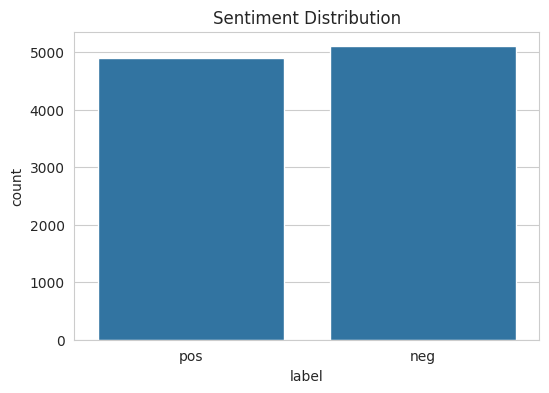

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='label',data=df)
plt.title("Sentiment Distribution")
plt.show()

review length

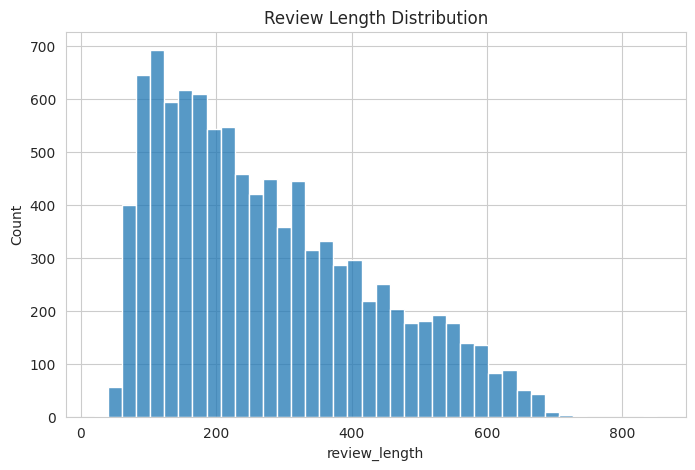

In [14]:
df['review_length'] = df['clean_review'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'],bins=40)
plt.title("Review Length Distribution")
plt.show()

word cloud

positive reviews

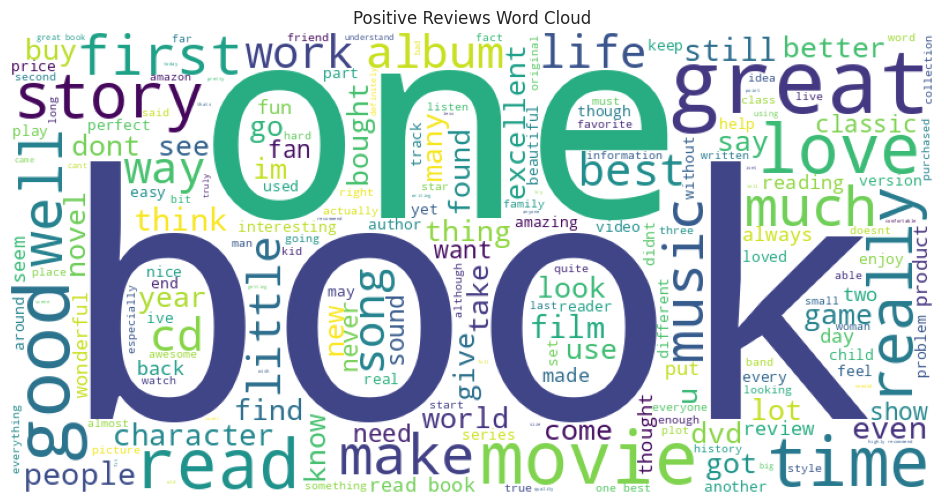

In [15]:
positive = " ".join(df[df.label=='pos']['clean_review'])

wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=400).generate(positive)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews Word Cloud")

plt.show()

negative reviews

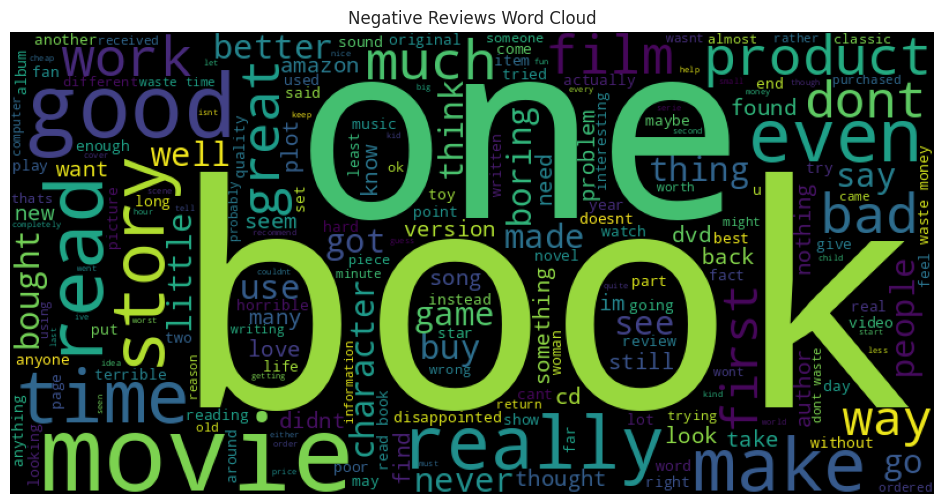

In [16]:
negative = " ".join(df[df.label=='neg']['clean_review'])

wordcloud = WordCloud(background_color='black',
                      width=800,
                      height=400).generate(negative)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

most common positive reviews

In [17]:
from collections import Counter

positive_words = positive.split()
common_positive = Counter(positive_words).most_common(20)
positive_df = pd.DataFrame(common_positive,columns=['Word','Count'])
positive_df

,Word,Count
0,book,3861
1,great,2089
2,one,1936
3,good,1637
4,read,1574
5,like,1320
6,movie,1295
7,time,1136
8,love,1038
9,would,943


most common negative words

In [18]:
negative_words = negative.split()
common_negative = Counter(negative_words).most_common(20)
negative_df = pd.DataFrame(common_negative,columns=['Word','Count'])
negative_df

,Word,Count
0,book,3683
1,one,2119
2,movie,1732
3,like,1570
4,would,1438
5,get,1285
6,time,1275
7,dont,1240
8,read,1238
9,good,1137


plot

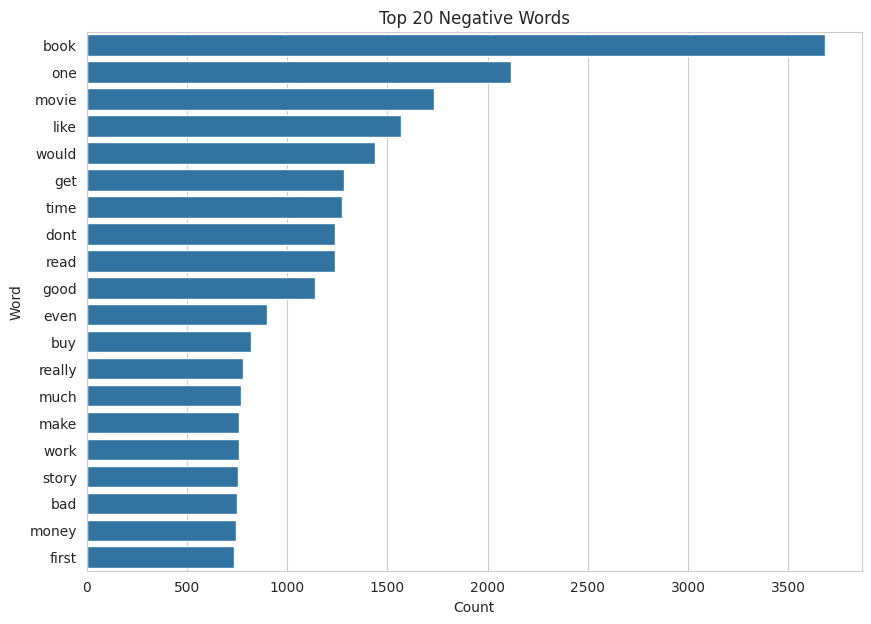

In [43]:
plt.figure(figsize=(10,7))
sns.barplot(data=negative_df,x='Count',y='Word')
plt.title("Top 20 Negative Words")
plt.show()

feature extraction(TF-IDF)

In [20]:
X = df['clean_review']
y = df['label']

In [21]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

train test split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logistic regression model

In [23]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

prediction

In [24]:
y_pred = lr.predict(X_test)

accuracy

In [25]:
accuracy_score(y_test,y_pred)

0.8465

classification  report

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.84      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



confusion matrix

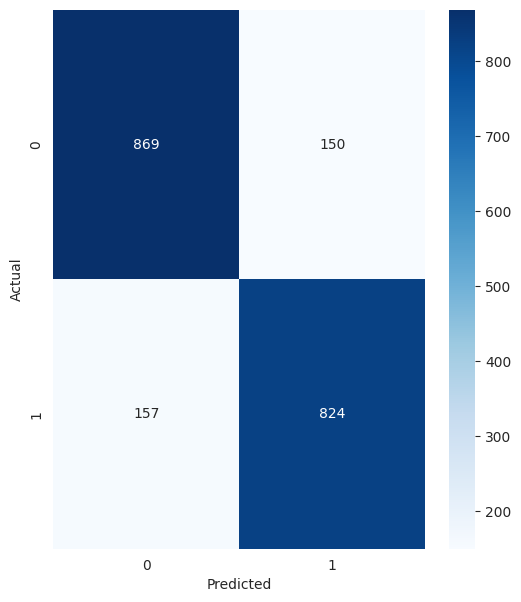

In [42]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

support vectir machine

In [28]:
svm = LinearSVC()
svm.fit(X_train,y_train)

LinearSVC()

prediction

In [29]:
svm_pred = svm.predict(X_test)

accuracy

In [30]:
accuracy_score(y_test,svm_pred)

0.832

classification report

In [31]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

         neg       0.84      0.83      0.83      1019
         pos       0.82      0.84      0.83       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



cross vadilation

logistic regression

In [32]:
scores = cross_val_score(lr,X,y,cv=5)
scores

array([0.85  , 0.826 , 0.819 , 0.8265, 0.8465])

In [40]:
scores = cross_val_score(lr,X,y,cv=4)
print("Average Accuracy :",scores.mean())

Average Accuracy : 0.8350000000000001


svm

In [41]:
scores = cross_val_score(svm,X,y,cv=4)
print(scores)
print(scores.mean())

[0.8388 0.8088 0.8028 0.8344]
0.8212


hyperparameter tuning

In [39]:
param_grid = {
    'C':[0.01,0.1,1,10]
}
grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=4)

grid.fit(X_train,y_train)

grid.best_params_

best_model = grid.best_estimator_

prediction = best_model.predict(X_test)
print(classification_report(y_test,prediction))




              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.84      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



compare models

In [36]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Linear SVM"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,svm_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.8465
1,Linear SVM,0.8320


visualization

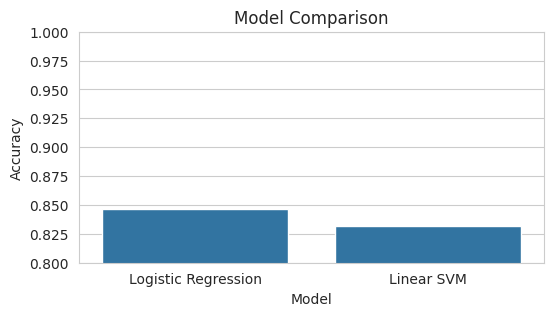

In [38]:
plt.figure(figsize=(6,3))
sns.barplot(data=results,x="Model",y="Accuracy")
plt.ylim(0.8,1)
plt.title("Model Comparison")
plt.show()

predict new reviews

In [44]:
review = ["The product quality is amazing and worth every penny"]

review = [clean_text(i) for i in review]
review = vectorizer.transform(review)
prediction = best_model.predict(review)
print(prediction)

['pos']


In [45]:
review = ["Worst purchase ever. Completely disappointed."]

review = [clean_text(i) for i in review]
review = vectorizer.transform(review)
prediction = best_model.predict(review)
print(prediction)

['neg']
